# RoadSafe India — State Accident Trends

## Objective

This notebook examines how reported road accidents vary across States/UTs
between 2020 and 2024.

The analysis focuses on:

1. Average accident burden across the five-year period.
2. Change in reported accidents between 2020 and 2024.
3. Consistency of high accident counts across the study period.

The purpose is to distinguish persistent accident burden from short-term
changes in individual years.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load cleaned accident data
accident_path = (
    "../data/processed/"
    "state_wise_road_accidents_2020_2024_cleaned.csv"
)

df = pd.read_csv(accident_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 39
Columns: 14


In [3]:
# Remove rows with missing State/UT or missing accident values
state_df = df[
    df["state"].notna()
].copy()

# Remove aggregate rows such as "Total (All India)"
state_df = state_df[
    ~state_df["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

# Keep only rows with a valid 2020–2024 accident record
year_columns = [
    "2020_accidents",
    "2021_accidents",
    "2022_accidents",
    "2023_accidents",
    "2024_accidents"
]

state_df = state_df.dropna(
    subset=year_columns
)

print(f"State/UT records used for analysis: {len(state_df)}")

State/UT records used for analysis: 35


In [4]:
years = [2020, 2021, 2022, 2023, 2024]

print("Study period:", years)

Study period: [2020, 2021, 2022, 2023, 2024]


In [5]:
# Calculate average reported accidents over 2020–2024

state_df["five_year_average"] = (
    state_df[year_columns].mean(axis=1)
)

display(
    state_df[
        [
            "state",
            *year_columns,
            "five_year_average"
        ]
    ].sort_values(
        "five_year_average",
        ascending=False
    ).head(10)
)

,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,five_year_average
22,Tamil Nadu,49844.0,55682.0,64105.0,67213.0,67526.0,60874.0
12,Madhya Pradesh,45266.0,48877.0,54432.0,55327.0,56669.0,52114.2
26,Uttar Pradesh,34243.0,37729.0,41746.0,44534.0,46052.0,40860.8
11,Kerala,27877.0,33296.0,43910.0,48091.0,48834.0,40401.6
10,Karnataka,34178.0,34647.0,39762.0,43440.0,43062.0,39017.8
13,Maharashtra,24971.0,29477.0,33383.0,35243.0,36118.0,31838.4
20,Rajasthan,19114.0,20951.0,23614.0,24694.0,24838.0,22642.2
23,Telangana,19172.0,21315.0,21619.0,22903.0,25986.0,22199.0
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,20364.0
6,Gujarat,13398.0,15186.0,15751.0,16349.0,15588.0,15254.4


In [6]:
# Absolute change between 2020 and 2024

state_df["change_2020_to_2024"] = (
    state_df["2024_accidents"]
    - state_df["2020_accidents"]
)

# Percentage change between 2020 and 2024

state_df["percent_change_2020_to_2024"] = (
    state_df["change_2020_to_2024"]
    / state_df["2020_accidents"]
    * 100
)

display(
    state_df[
        [
            "state",
            "2020_accidents",
            "2024_accidents",
            "change_2020_to_2024",
            "percent_change_2020_to_2024"
        ]
    ].sort_values(
        "percent_change_2020_to_2024",
        ascending=False
    ).head(10)
)

,state,2020_accidents,2024_accidents,change_2020_to_2024,percent_change_2020_to_2024
16,Mizoram,53.0,118.0,65.0,122.641509
1,Arunachal Pradesh,134.0,277.0,143.0,106.716418
11,Kerala,27877.0,48834.0,20957.0,75.176669
25,Uttarakhand,1041.0,1747.0,706.0,67.819404
30,Dadra & Nagar Haveli and Daman & Diu,100.0,152.0,52.0,52.000000
35,Puducherry,969.0,1431.0,462.0,47.678019
13,Maharashtra,24971.0,36118.0,11147.0,44.639782
23,Telangana,19172.0,25986.0,6814.0,35.541415
22,Tamil Nadu,49844.0,67526.0,17682.0,35.474681
31,Delhi,4178.0,5657.0,1479.0,35.399713


In [7]:
largest_increases = (
    state_df
    .sort_values(
        "change_2020_to_2024",
        ascending=False
    )
    .head(10)
)

print("States/UTs with the largest absolute increase in reported accidents:")
display(
    largest_increases[
        [
            "state",
            "2020_accidents",
            "2024_accidents",
            "change_2020_to_2024",
            "percent_change_2020_to_2024"
        ]
    ]
)

States/UTs with the largest absolute increase in reported accidents:


,state,2020_accidents,2024_accidents,change_2020_to_2024,percent_change_2020_to_2024
11,Kerala,27877.0,48834.0,20957.0,75.176669
22,Tamil Nadu,49844.0,67526.0,17682.0,35.474681
26,Uttar Pradesh,34243.0,46052.0,11809.0,34.485880
12,Madhya Pradesh,45266.0,56669.0,11403.0,25.191093
13,Maharashtra,24971.0,36118.0,11147.0,44.639782
10,Karnataka,34178.0,43062.0,8884.0,25.993329
23,Telangana,19172.0,25986.0,6814.0,35.541415
20,Rajasthan,19114.0,24838.0,5724.0,29.946636
4,Chhattisgarh,11656.0,14857.0,3201.0,27.462251
3,Bihar,8639.0,11610.0,2971.0,34.390554


In [8]:
largest_decreases = (
    state_df
    .sort_values(
        "change_2020_to_2024",
        ascending=True
    )
    .head(10)
)

print("States/UTs with the largest absolute decrease in reported accidents:")
display(
    largest_decreases[
        [
            "state",
            "2020_accidents",
            "2024_accidents",
            "change_2020_to_2024",
            "percent_change_2020_to_2024"
        ]
    ]
)

States/UTs with the largest absolute decrease in reported accidents:


,state,2020_accidents,2024_accidents,change_2020_to_2024,percent_change_2020_to_2024
17,Nagaland,500.0,129.0,-371.0,-74.200000
14,Manipur,432.0,299.0,-133.0,-30.787037
8,Himachal Pradesh,2239.0,2156.0,-83.0,-3.707012
28,Andaman & Nicobar Islands,141.0,135.0,-6.0,-4.255319
34,Lakshadweep,1.0,0.0,-1.0,-100.000000
29,Chandigarh,159.0,169.0,10.0,6.289308
21,Sikkim,138.0,149.0,11.0,7.971014
0,Andhra Pradesh,19509.0,19557.0,48.0,0.246040
30,Dadra & Nagar Haveli and Daman & Diu,100.0,152.0,52.0,52.000000
15,Meghalaya,214.0,269.0,55.0,25.700935


In [9]:
# Count how many times each State/UT appears in the top 10
# across the five years.

top10_counts = {}

for year_column in year_columns:

    yearly_top10 = (
        state_df
        .nlargest(10, year_column)["state"]
    )

    for state in yearly_top10:
        top10_counts[state] = (
            top10_counts.get(state, 0) + 1
        )

top10_persistence = (
    pd.DataFrame(
        list(top10_counts.items()),
        columns=[
            "state",
            "years_in_top_10"
        ]
    )
    .sort_values(
        "years_in_top_10",
        ascending=False
    )
    .reset_index(drop=True)
)

display(top10_persistence)

,state,years_in_top_10
0,Tamil Nadu,5
1,Madhya Pradesh,5
2,Uttar Pradesh,5
3,Karnataka,5
4,Kerala,5
5,Maharashtra,5
6,Andhra Pradesh,5
7,Telangana,5
8,Rajasthan,5
9,Gujarat,5


In [17]:
trend_table = state_df[
    [
        "state",
        "2020_accidents",
        "2021_accidents",
        "2022_accidents",
        "2023_accidents",
        "2024_accidents",
        "five_year_average",
        "change_2020_to_2024",
        "percent_change_2020_to_2024"
    ]
].copy()

display(
    trend_table.sort_values(
        "five_year_average",
        ascending=False
    ).head(15)
)

,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,five_year_average,change_2020_to_2024,percent_change_2020_to_2024
22,Tamil Nadu,49844.0,55682.0,64105.0,67213.0,67526.0,60874.0,17682.0,35.474681
12,Madhya Pradesh,45266.0,48877.0,54432.0,55327.0,56669.0,52114.2,11403.0,25.191093
26,Uttar Pradesh,34243.0,37729.0,41746.0,44534.0,46052.0,40860.8,11809.0,34.485880
11,Kerala,27877.0,33296.0,43910.0,48091.0,48834.0,40401.6,20957.0,75.176669
10,Karnataka,34178.0,34647.0,39762.0,43440.0,43062.0,39017.8,8884.0,25.993329
13,Maharashtra,24971.0,29477.0,33383.0,35243.0,36118.0,31838.4,11147.0,44.639782
20,Rajasthan,19114.0,20951.0,23614.0,24694.0,24838.0,22642.2,5724.0,29.946636
23,Telangana,19172.0,21315.0,21619.0,22903.0,25986.0,22199.0,6814.0,35.541415
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,20364.0,48.0,0.246040
6,Gujarat,13398.0,15186.0,15751.0,16349.0,15588.0,15254.4,2190.0,16.345723


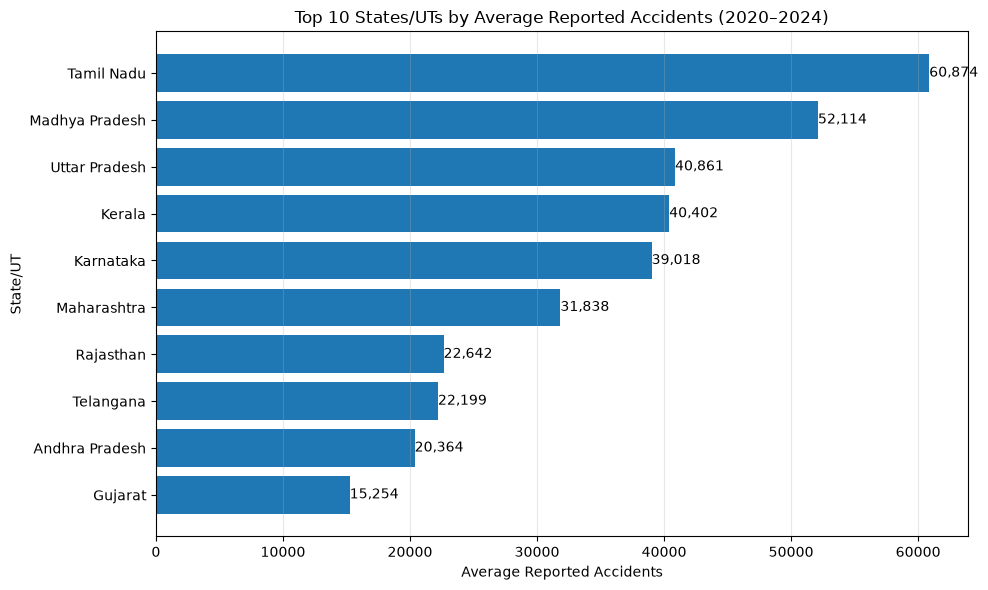

In [11]:
top_average = (
    state_df
    .sort_values(
        "five_year_average",
        ascending=False
    )
    .head(10)
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_average["state"],
    top_average["five_year_average"]
)

plt.title(
    "Top 10 States/UTs by Average Reported Accidents (2020–2024)"
)

plt.xlabel("Average Reported Accidents")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

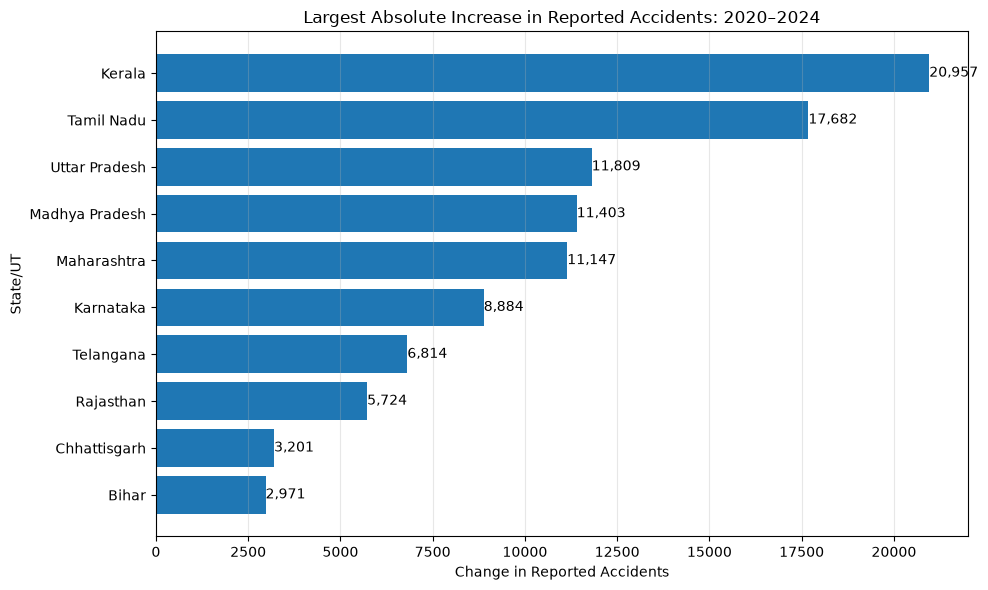

In [12]:
top_changes = (
    state_df
    .sort_values(
        "change_2020_to_2024",
        ascending=False
    )
    .head(10)
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_changes["state"],
    top_changes["change_2020_to_2024"]
)

plt.title(
    "Largest Absolute Increase in Reported Accidents: 2020–2024"
)

plt.xlabel("Change in Reported Accidents")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
state_name = "Tamil Nadu"

selected_state = state_df[
    state_df["state"] == state_name
]

trend_values = selected_state[
    year_columns
].iloc[0]

trend_df = pd.DataFrame({
    "year": years,
    "accidents": trend_values.values
})

display(trend_df)

,year,accidents
0,2020,49844.0
1,2021,55682.0
2,2022,64105.0
3,2023,67213.0
4,2024,67526.0


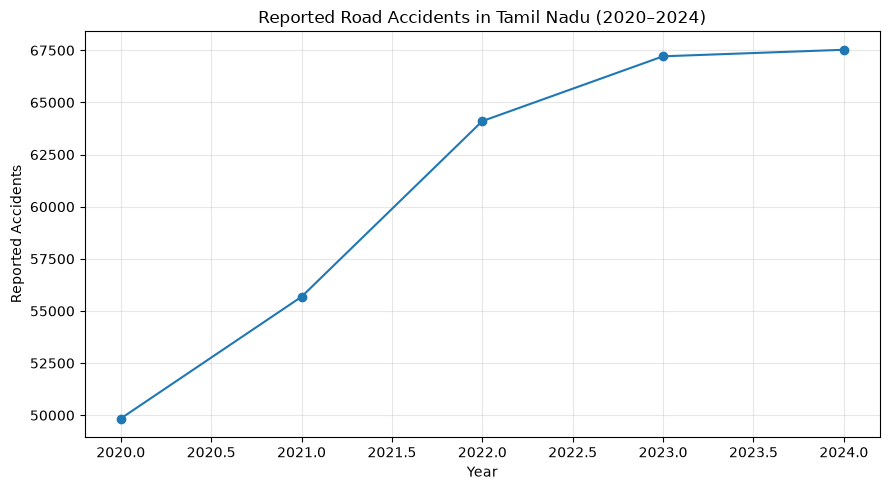

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    trend_df["year"],
    trend_df["accidents"],
    marker="o"
)

plt.title(
    f"Reported Road Accidents in {state_name} (2020–2024)"
)

plt.xlabel("Year")
plt.ylabel("Reported Accidents")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
trend_output_path = (
    "../data/processed/"
    "state_accident_trends_2020_2024.csv"
)

trend_table.to_csv(
    trend_output_path,
    index=False
)

print("State trend dataset saved:")
print(trend_output_path)

State trend dataset saved:
../data/processed/state_accident_trends_2020_2024.csv


## Initial Findings

The five-year analysis allows States/UTs to be evaluated not only by their
accident count in a single year but also by their average accident burden
across 2020–2024.

The analysis also identifies States/UTs with large absolute changes between
2020 and 2024 and States/UTs that repeatedly appear among the top ten
highest-accident States.

These measures provide different perspectives:

- Five-year average → persistent accident burden.
- 2020–2024 change → change in reported accident burden.
- Top-10 persistence → consistency of high ranking.

The 2020–2024 period should be interpreted carefully because accident and
mobility patterns in 2020 and 2021 were affected by exceptional circumstances.
Therefore, changes between 2020 and later years should not automatically be
interpreted as changes in underlying road-safety risk.

## Key Findings

Tamil Nadu recorded the highest five-year average of reported road accidents
among the States/UTs in the dataset, with an average of 60,874 accidents per
year between 2020 and 2024.

Madhya Pradesh ranked second with an average of 52,114.2 reported accidents,
followed by Uttar Pradesh and Kerala.

The five-year analysis also shows that States/UTs can have very different
trajectories. For example, Andhra Pradesh recorded nearly the same number of
reported accidents in 2020 and 2024, while Kerala experienced a substantial
increase over the same period.

Therefore, a single-year ranking does not fully capture the evolution of
accident burden. Both persistent burden and temporal change should be
considered.

The 2020–2024 period should also be interpreted cautiously because 2020 and
2021 were affected by exceptional mobility conditions.

In [18]:
top10_persistence

,state,years_in_top_10
0,Tamil Nadu,5
1,Madhya Pradesh,5
2,Uttar Pradesh,5
3,Karnataka,5
4,Kerala,5
5,Maharashtra,5
6,Andhra Pradesh,5
7,Telangana,5
8,Rajasthan,5
9,Gujarat,5
